In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
BASE_PATH = Path(r"C:\be project 25-26\anemia-project\data\raw")
ANERBC_HEALTHY = BASE_PATH/ "AneRBC"/ "AneRBC_dataset" / "AneRBC-II" / "Healthy_individuals" / "Original_Images"
ANERBC_ANEMIC = BASE_PATH/ "AneRBC"/ "AneRBC_dataset" / "AneRBC-II" / "Anemic_individuals" / "Original_Images"
for p in [BASE_PATH, ANERBC_HEALTHY, ANERBC_ANEMIC]:
    p.mkdir(parents=True, exist_ok=True)

print("ANERBC Healthy:", ANERBC_HEALTHY, "| Exists:", ANERBC_HEALTHY.exists())
print("ANERBC Anemic:", ANERBC_ANEMIC, "| Exists:", ANERBC_ANEMIC.exists())

ANERBC Healthy: C:\be project 25-26\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Healthy_individuals\Original_Images | Exists: True
ANERBC Anemic: C:\be project 25-26\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Anemic_individuals\Original_Images | Exists: True


In [3]:
def count_images(folder_path):
    folder=Path(folder_path)
    if not folder.exists():
        return 0, []
    extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tif', 'tiff', 'JPG', 'JPEG', 'PNG']
    images = []
    for ext in extensions:
        images.extend(list(folder.rglob(f'*.{ext}')))
    images=list(set(images))
    return len(images), [str(p) for p in images]

anerbc_h_count, anerbc_h_list = count_images(ANERBC_HEALTHY)
anerbc_a_count, anerbc_a_list = count_images(ANERBC_ANEMIC)
anerbc_total = anerbc_h_count + anerbc_a_count
anerbc_list = anerbc_h_list + anerbc_a_list
print(f"AneRBC Healthy: {anerbc_h_count} images")
print(f"AneRBC Anemic: {anerbc_a_count} images")
print(f"AneRBC Total: {anerbc_total} images")

AneRBC Healthy: 6000 images
AneRBC Anemic: 5999 images
AneRBC Total: 11999 images


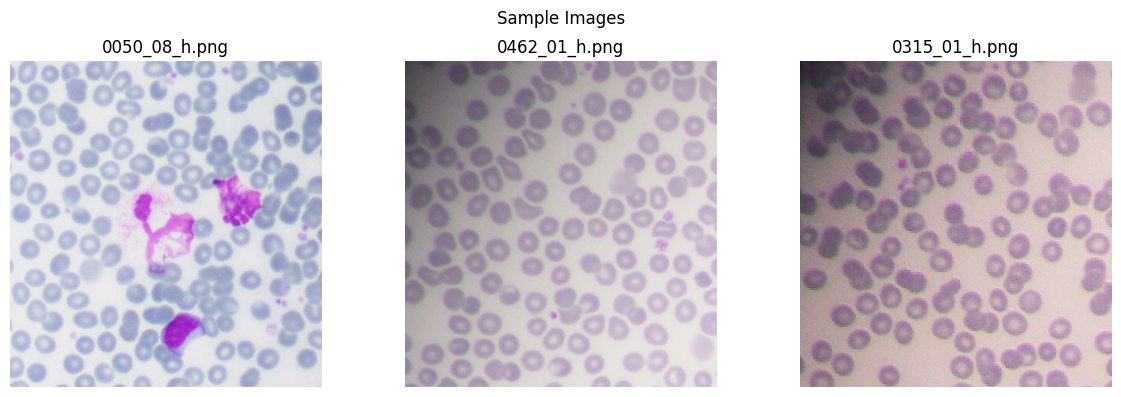

In [4]:
def show_sample(image_paths, title="Sample", cols=3):
    n=min(len(image_paths), cols)
    if n==0:
        print("No images to show.")
        return 
    fig, axes = plt.subplots(1,n, figsize=(4*n, 4))
    if n==1:
        axes = [axes]
    for i, ax in enumerate(axes):
        img = Image.open(image_paths[i]).convert('RGB')
        ax.imshow(img)
        ax.set_title(Path(image_paths[i]).name[:25])
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

all_images = anerbc_list
if all_images:
    show_sample(all_images[:3], "Sample Images")
else:
    print("No images found. Check paths.")

In [5]:
if anerbc_list:
    sample_path= (anerbc_list)[0]
    img = Image.open(sample_path)
    print(f"Sample: {Path(sample_path).name}")
    print(f"Size: {img.size} (width x height)")
    print(f"Mode: {img.mode}")
else:
    print("No images to check.")

Sample: 0050_08_h.png
Size: (306, 320) (width x height)
Mode: RGB


In [6]:
summary = pd.DataFrame({
    "Dataset": ["AneRBC Healthy", "AneRBC Anemic"],
    "Count": [anerbc_h_count, anerbc_a_count],
    "Path": [str(ANERBC_HEALTHY), str(ANERBC_ANEMIC)]
})
print(summary.to_string(index=False))
print(f"\nTotal Images: {anerbc_total}")

       Dataset  Count                                                                                                            Path
AneRBC Healthy   6000 C:\be project 25-26\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Healthy_individuals\Original_Images
 AneRBC Anemic   5999  C:\be project 25-26\anemia-project\data\raw\AneRBC\AneRBC_dataset\AneRBC-II\Anemic_individuals\Original_Images

Total Images: 11999


In [7]:
pip install staintools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


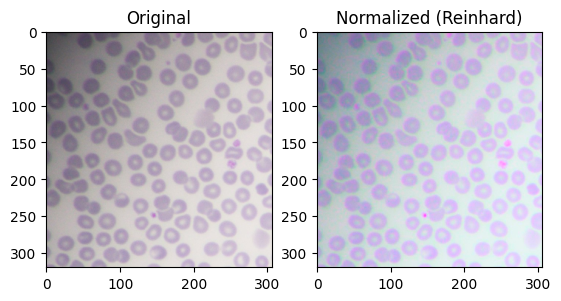

In [8]:
import numpy as np
from PIL import Image
from pathlib import Path

def reinhard_normalize(img_array, reference_path):
    from skimage import exposure
    from skimage.color import rgb2lab, lab2rgb

    ref = np.array(Image.open(reference_path).convert('RGB'))
    ref_lab = rgb2lab(ref)
    img_lab = rgb2lab(img_array)

    for i in range(3):
        img_lab[:,:,i] = (img_lab[:,:,i] - img_lab[:,:,i].mean()) * (ref_lab[:,:,i].std() / (img_lab[:,:,i].std() + 1e-8)) + ref_lab[:,:,i].mean()
        
    return (lab2rgb(img_lab) * 255).astype(np.uint8)

ref_path=anerbc_list[0]
img_path=anerbc_list[1]
img = np.array(Image.open(img_path).convert('RGB'))
normalized = reinhard_normalize(img, ref_path)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(normalized)
axes[1].set_title("Normalized (Reinhard)")
plt.show()

In [9]:
from pathlib import Path
from sklearn.model_selection import train_test_split

BASE = Path(r"C:\be project 25-26\anemia-project\data\raw")
ANERBC_H = BASE_PATH/ "AneRBC"/ "AneRBC_dataset" / "AneRBC-II" / "Healthy_individuals" / "Original_Images"
ANERBC_A = BASE_PATH/ "AneRBC"/ "AneRBC_dataset" / "AneRBC-II" / "Anemic_individuals" / "Original_Images"

image_paths=[]
labels=[]
for p in ANERBC_H.rglob("*.png"):
    image_paths.append(str(p))
    labels.append(0)
for p in ANERBC_A.rglob("*.png"):
    image_paths.append(str(p))
    labels.append(1)
print(f"Total: {len(image_paths)} | Healthy: {labels.count(0)} | Anemic: {labels.count(1)}")

Total: 11999 | Healthy: 6000 | Anemic: 5999


In [10]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

Train: 9599 | Val: 2400


In [11]:
splits_dir = Path(r"C:\be project 25-26\anemia-project\data\processed\splits")
splits_dir.mkdir(parents=True, exist_ok=True)

for name, paths, lbls in [("train", train_paths, train_labels), ("val", val_paths, val_labels)]:
    with open(splits_dir / f"{name}_paths.txt", "w") as f:
        f.write("\n".join(paths))
    with open(splits_dir / f"{name}_labels.txt", "w") as f:
        f.write("\n".join(map(str, lbls)))
print("Saved to data/processed/splits/")

Saved to data/processed/splits/


In [12]:
import sys
sys.path.insert(0, r"C:\be project 25-26\anemia-project\src")
import importlib
import utils.data_loader

importlib.reload(utils.data_loader)
from utils.data_loader import PBSDataset

In [13]:
dataset = PBSDataset([1,2,3], [0,1,0])
print(hasattr(dataset, "__len__"))
print(len(dataset))

True
3


In [14]:
import sys
sys.path.insert(0, str(Path(r"C:\be project 25-26\anemia-project\src")))
from utils.data_loader import PBSDataset, get_transforms
from torch.utils.data import DataLoader

train_dataset = PBSDataset(train_paths, train_labels, transform=get_transforms(train=True))
val_dataset = PBSDataset(val_paths, val_labels, transform=get_transforms(train=False))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
print(f"Batch shape: {batch_x.shape} | Labels: {batch_y.shape}")

Batch shape: torch.Size([32, 3, 224, 224]) | Labels: torch.Size([32])


In [37]:
import torch
import torch.nn as nn
import sys
from pathlib import Path
sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))

from models.cnn_baseline import get_cnn_model
from models.train import train_one_epoch, validate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_cnn_model(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
best_val_acc = 0.0

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_cnn.pt")
        print(f"  -> Saved best model (val_acc={val_acc:.4f})")


Train: 100%|██████████████████████████████████████████████████████████████████████████████████████| 300/300 [17:07<00:00,  3.42s/it]


Epoch 1/10 | Train Loss: 0.3006 Acc: 0.8557 | Val Loss: 0.1958 Acc: 0.9038
  -> Saved best model (val_acc=0.9038)


Train: 100%|██████████████████████████████████████████████████████████████████████████████████████| 300/300 [16:09<00:00,  3.23s/it]


Epoch 2/10 | Train Loss: 0.2061 Acc: 0.9001 | Val Loss: 0.1711 Acc: 0.9104
  -> Saved best model (val_acc=0.9104)


Train: 100%|██████████████████████████████████████████████████████████████████████████████████████| 300/300 [16:09<00:00,  3.23s/it]


...

Epoch 8/10 | Train Loss: 0.1051 Acc: 0.9534 | Val Loss: 0.1162 Acc: 0.9471


Train: 100%|██████████████████████████████████████████████████████████████████████████████████████| 300/300 [14:46<00:00,  2.96s/it]


Epoch 9/10 | Train Loss: 0.0996 Acc: 0.9567 | Val Loss: 0.0894 Acc: 0.9600
  -> Saved best model (val_acc=0.9600)


Train: 100%|██████████████████████████████████████████████████████████████████████████████████████| 300/300 [15:43<00:00,  3.14s/it]


Epoch 10/10 | Train Loss: 0.0980 Acc: 0.9581 | Val Loss: 0.0947 Acc: 0.9587


In [44]:
import sys
from pathlib import Path
import numpy as np

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from features.handcrafted_features import extract_all_features, extract_features_batch

# Test on one image
feat = extract_all_features(train_paths[0])
print(f"Feature vector shape: {feat.shape}")
print(f"Features: morph(6) + texture(4) + color(4) = 14")

# Test on batch (first 10)
feats = extract_features_batch(train_paths[:10])
print(f"Batch shape: {feats.shape}")


ValueError: homogenity is an invalid property

In [ ]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sys.path.insert(0, str(Path(r"C:\Users\nshivane\anemia-project\src")))
from utils.data_loader import get_transforms
from utils.hybrid_dataset import HybridDataset
from features.handcrafted_features import extract_features_batch
from models.hybrid_model import HybridModel

print("Extracting handcrafted features...")
train_hand = extract_features_batch(train_paths)
val_hand = extract_features_batch(val_paths)

scaler = StandardScaler()
train_hand = scaler.fit_transform(train_hand)
val_hand = scaler.transform(val_hand)

train_ds = HybridDataset(train_paths, train_labels, train_hand, transform=get_transforms(train=True))
val_ds = HybridDataset(val_paths, val_labels, val_hand, transform=get_transforms(train=False))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

model = HybridModel(num_classes=2, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()

model.train()
for imgs, hand_feat, labels in train_loader:
    imgs = imgs.to(device)
    hand_feat = hand_feat.to(device)
    labels = labels.to(device)
    logits = model(imgs, hand_feat)
    loss = criterion(logits, labels)
    print(f"Batch loss: {loss.item():.4f}")
    break
print("Forward pass OK!")


In [ ]:
# Full training loop (10 epochs)
from tqdm import tqdm

num_epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Optional: save best model
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for imgs, hand_feat, labels in tqdm(train_loader, desc="Train"):
        imgs, hand_feat, labels = imgs.to(device), hand_feat.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs, hand_feat)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, hand_feat, labels in val_loader:
            imgs, hand_feat, labels = imgs.to(device), hand_feat.to(device), labels.to(device)
            logits = model(imgs, hand_feat)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    tr_acc = train_correct / train_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} Acc: {tr_acc:.4f} | Val Loss: {val_loss/len(val_loader):.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_hybrid.pt")
        print(f"  -> Saved best model (val_acc={val_acc:.4f})")